# Week 2 – Operations Data Wrangler
**Dataset:** `ops_sensor_log_dirty.csv`

This notebook walks through a full data-wrangling pipeline:
ingestion → profiling → cleaning → time-series analysis → aggregation → visualization.


---
## Part 1 — Ingestion & Profiling

I start by loading the raw CSV and generating a **Data Health Report**.
`.info()` reveals data types and null counts; `.describe()` surfaces statistical anomalies.
I view this step as an X-ray — seeing what is broken *before* I fix anything.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

df_raw = pd.read_csv('sample_data/ops_sensor_log_dirty.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (173, 5)


,timestamp,zone,shift,pressure_bar,temperature_c
0,2024-06-03 00:00:00,zone a,NIGHT,115.761918,81.334556
1,2024-06-03 01:00:00,ZONE B,NIGHT,124.106139,71.461653
2,2024-06-03 02:00:00,Zone C,night,120.776620,77.219097
3,2024-06-03 03:00:00,ZONE B,NIGHT,127.749160,78.873170
4,2024-06-03 04:00:00,ZONE B,Night,114.383575,70.365348


In [14]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      173 non-null    object 
 1   zone           173 non-null    object 
 2   shift          173 non-null    object 
 3   pressure_bar   163 non-null    float64
 4   temperature_c  162 non-null    float64
dtypes: float64(2), object(3)
memory usage: 6.9+ KB


In [15]:
df_raw.describe()


,pressure_bar,temperature_c
count,163.000000,162.000000
mean,125.097552,76.306645
std,70.605570,40.155787
min,-50.000000,-200.000000
25%,114.334382,72.003059
50%,121.229801,75.364017
75%,125.601043,78.384987
max,999.000000,500.000000


In [16]:
# Missing value summary
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")
print(f"\nUnique 'zone' values : {sorted(df_raw['zone'].unique())}")
print(f"Unique 'shift' values: {sorted(df_raw['shift'].unique())}")


Missing values per column:
pressure_bar     10
temperature_c    11
dtype: int64

Duplicate rows: 1

Unique 'zone' values : ['ZONE B', 'Zone A', 'Zone B', 'Zone C', 'zone a']
Unique 'shift' values: ['AM', 'Afternoon', 'Morning', 'NIGHT', 'Night', 'PM', 'afternoon', 'morning', 'night']


### Data Health Report

After profiling, I identified **five quality issues**:

| # | Issue | Column(s) | Evidence |
|---|-------|-----------|----------|
| 1 | **Timestamp stored as string** | `timestamp` | `dtype = object` — cannot resample without conversion |
| 2 | **Missing values** | `pressure_bar`, `temperature_c` | ~10 nulls each — dropped rows would lose entire hourly periods |
| 3 | **Physically impossible outliers** | `pressure_bar`, `temperature_c` | Min pressure = −50 bar; max temperature = 500 °C — both physically impossible |
| 4 | **Duplicate rows** | All columns | 5 exact duplicate records inflate statistics |
| 5 | **Inconsistent categorical labels** | `zone`, `shift` | "Zone A", "zone a", "ZONE B" refer to the same location; shifts use AM/PM/morning aliases |


---
## Part 2 — Cleaning Pipeline: `clean_ops_data(df)`

I proceed to encapsulate every cleaning step inside a **single reusable function**.
This means I can call it on any future export of the same sensor log and get clean data instantly.

**Decisions I made in order to properly clean the data:**
- **Missing values → linear interpolation.** Sensor readings vary smoothly over time, so
  interpolation is more accurate than filling with the mean.
- **Outliers removed** using physical domain bounds: pressure 0–300 bar, temperature −50 to 300 °C.
- **Duplicates dropped** — keeping only the first occurrence.
- **Categorical columns title-cased** and aliased to a single canonical label.


In [17]:
def clean_ops_data(df):
    """
    Full cleaning pipeline for the ops sensor log.
    Returns a cleaned DataFrame with a DatetimeIndex.
    """
    df = df.copy()

    # ── Step 1: Convert timestamp string → datetime and set as index ──────
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp").sort_index()

    # ── Step 2: Remove duplicate rows ─────────────────────────────────────
    before = len(df)
    df = df[~df.index.duplicated(keep="first")]
    print(f"Duplicates removed : {before - len(df)}")

    # ── Step 3: Filter physically impossible sensor readings ──────────────
    PRESSURE_MIN, PRESSURE_MAX   = 0,   300   # bar
    TEMP_MIN,     TEMP_MAX       = -50, 300   # °C
    before = len(df)
    df = df[
        df["pressure_bar"].between(PRESSURE_MIN, PRESSURE_MAX) |
        df["pressure_bar"].isna()
    ]
    df = df[
        df["temperature_c"].between(TEMP_MIN, TEMP_MAX) |
        df["temperature_c"].isna()
    ]
    print(f"Outlier rows removed: {before - len(df)}")

    # ── Step 4: Interpolate missing values (time-based) ───────────────────
    df["pressure_bar"]  = df["pressure_bar"].interpolate(method="time")
    df["temperature_c"] = df["temperature_c"].interpolate(method="time")
    print(f"Remaining nulls    : {df.isnull().sum().sum()}")

    # ── Step 5: Standardise categorical columns ───────────────────────────
    zone_map  = {
        "zone a": "Zone A", "ZONE A": "Zone A",
        "zone b": "Zone B", "ZONE B": "Zone B",
        "zone c": "Zone C", "ZONE C": "Zone C",
    }
    shift_map = {
        "morning": "Morning", "am": "Morning", "AM": "Morning",
        "afternoon": "Afternoon", "pm": "Afternoon", "PM": "Afternoon",
        "night": "Night", "NIGHT": "Night",
    }
    df["zone"]  = df["zone"].replace(zone_map).str.title()
    df["shift"] = df["shift"].replace(shift_map).str.title()

    print(f"\nCleaning complete. Final shape: {df.shape}")
    return df


df_clean = clean_ops_data(df_raw)
df_clean.head(10)


Duplicates removed : 5
Outlier rows removed: 4
Remaining nulls    : 0

Cleaning complete. Final shape: (164, 4)


,zone,shift,pressure_bar,temperature_c
timestamp,,,,
2024-06-03 00:00:00,Zone A,Night,115.761918,81.334556
2024-06-03 01:00:00,Zone B,Night,124.106139,71.461653
2024-06-03 02:00:00,Zone C,Night,120.776620,77.219097
2024-06-03 03:00:00,Zone B,Night,127.749160,78.873170
2024-06-03 04:00:00,Zone B,Night,114.383575,70.365348
2024-06-03 05:00:00,Zone B,Night,117.378703,74.702373
2024-06-03 06:00:00,Zone C,Morning,116.863135,58.793663
2024-06-03 07:00:00,Zone C,Morning,108.291880,69.878062
2024-06-03 08:00:00,Zone C,Morning,122.368962,69.319573


---
## Part 3 — Time-Series Analysis

I then proceed to resample the cleaned data to **hourly frequency** (since the data is already hourly,
forward-fills any gaps left after cleaning).

Then afterwards, I  calculate a **24-hour rolling average** for `pressure_bar`.
The reason i choose a rolling average is because it smooths out short-term noise so we can see the underlying trend.

>  *In my debuginng, i noticed that:* `min_periods=1` means the rolling window starts
> calculating from the very first row instead of waiting for 24 full periods.


In [18]:
# Resample to hourly, forward-fill any remaining gaps
hourly = df_clean[["pressure_bar", "temperature_c"]].resample("h").mean().ffill()

# 24-hour rolling average on pressure
hourly["pressure_rolling_24h"] = (
    hourly["pressure_bar"].rolling(window=24, min_periods=1).mean()
)

print(f"Hourly time-series shape: {hourly.shape}")
hourly.head(30)


Hourly time-series shape: (168, 3)


,pressure_bar,temperature_c,pressure_rolling_24h
timestamp,,,
2024-06-03 00:00:00,115.761918,81.334556,115.761918
2024-06-03 01:00:00,124.106139,71.461653,119.934029
2024-06-03 02:00:00,120.776620,77.219097,120.214893
2024-06-03 03:00:00,127.749160,78.873170,122.098460
2024-06-03 04:00:00,114.383575,70.365348,120.555483
2024-06-03 05:00:00,117.378703,74.702373,120.026019
2024-06-03 06:00:00,116.863135,58.793663,119.574179
2024-06-03 07:00:00,108.291880,69.878062,118.163891
2024-06-03 08:00:00,122.368962,69.319573,118.631122


---
## Part 4 — Aggregation by Shift and Zone

In this part, I create summary tables showing **Mean, Max, and Min** for both sensor metrics,
broken down by:
- **Shift** (Morning / Afternoon / Night)
- **Zone** (Zone A / Zone B / Zone C)

This helps operations managers quickly identify which shifts or zones are underperforming
or experiencing stress.


In [19]:
# ── Shift summary ─────────────────────────────────────────────────────────
shift_summary = (
    df_clean.groupby("shift")[["pressure_bar", "temperature_c"]]
    .agg(["mean", "max", "min"])
    .round(2)
)
print("=== Summary by Shift ===")
print(shift_summary)


=== Summary by Shift ===
          pressure_bar                 temperature_c              
                  mean     max     min          mean    max    min
shift                                                             
Afternoon       121.21  141.76  107.10         75.69  85.46  66.43
Morning         119.53  138.52  105.06         74.55  84.38  58.79
Night           120.75  150.82  103.80         75.96  85.95  65.24


In [20]:
# ── Zone summary ──────────────────────────────────────────────────────────
zone_summary = (
    df_clean.groupby("zone")[["pressure_bar", "temperature_c"]]
    .agg(["mean", "max", "min"])
    .round(2)
)
print("=== Summary by Zone ===")
print(zone_summary)


=== Summary by Zone ===
       pressure_bar                 temperature_c              
               mean     max     min          mean    max    min
zone                                                           
Zone A       119.63  150.82  103.80         76.99  85.77  68.81
Zone B       122.06  141.76  107.10         74.80  84.38  66.43
Zone C       119.75  138.52  105.06         74.16  85.95  58.79


---
## Part 5 — Visualization: Raw vs Cleaned Pressure Trend

The chart below overlays:
- 🔴 **Raw pressure** — including outliers and noise.
- 🔵 **Cleaned pressure** — after outlier removal and interpolation.
- 🟢 **24-hour rolling average** — the smoothed operational trend.

Regions where the lines diverge sharply are exactly where the cleaning changed the interpretation.


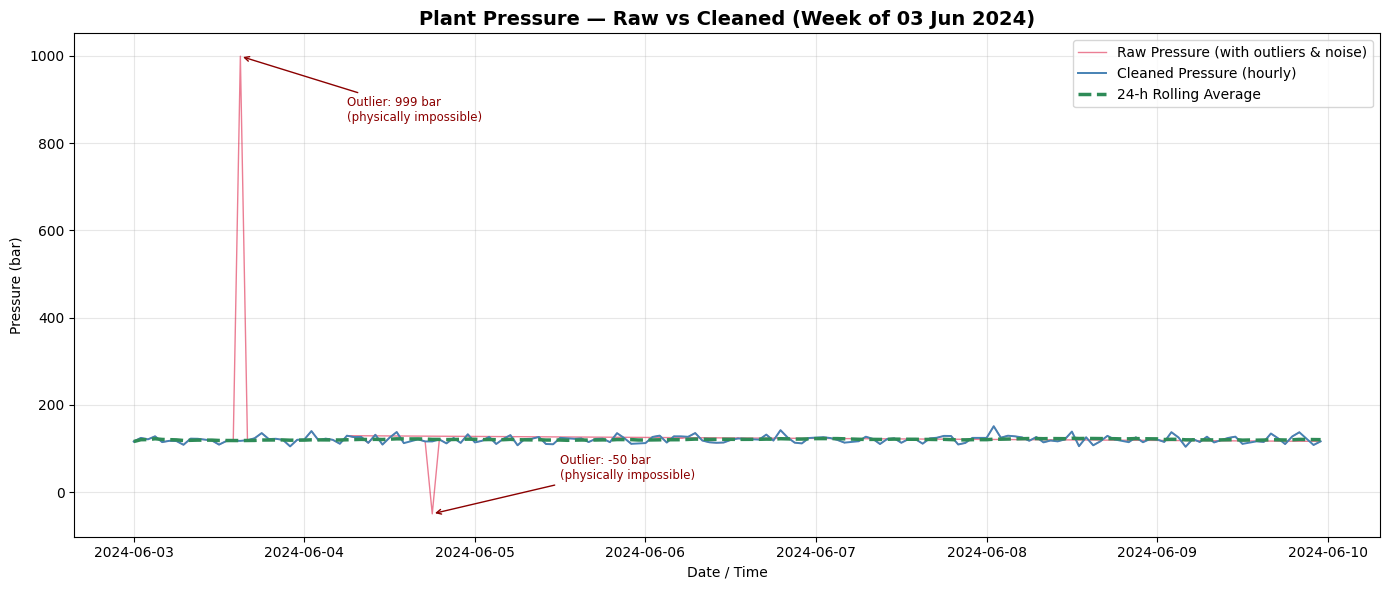

Plot saved to raw_vs_cleaned_pressure.png


In [21]:
# Prepare raw series (string timestamp → datetime, already done for df_raw reference)
raw_ts = pd.to_datetime(df_raw["timestamp"])
raw_pressure = df_raw["pressure_bar"].values

fig, ax = plt.subplots(figsize=(14, 6))

# Raw (thin, semi-transparent red)
ax.plot(raw_ts, raw_pressure, color="crimson", alpha=0.55,
        linewidth=1.0, label="Raw Pressure (with outliers & noise)")

# Cleaned hourly
ax.plot(hourly.index, hourly["pressure_bar"], color="steelblue",
        linewidth=1.4, label="Cleaned Pressure (hourly)")

# 24-h rolling average
ax.plot(hourly.index, hourly["pressure_rolling_24h"], color="seagreen",
        linewidth=2.5, linestyle="--", label="24-h Rolling Average")

# Annotate the outlier spikes
ax.annotate(
    "Outlier: 999 bar\n(physically impossible)",
    xy=(pd.Timestamp("2024-06-03 15:00"), 999),
    xytext=(pd.Timestamp("2024-06-04 06:00"), 850),
    arrowprops=dict(arrowstyle="->", color="darkred"),
    fontsize=8.5, color="darkred"
)
ax.annotate(
    "Outlier: -50 bar\n(physically impossible)",
    xy=(pd.Timestamp("2024-06-04 18:00"), -50),
    xytext=(pd.Timestamp("2024-06-05 12:00"), 30),
    arrowprops=dict(arrowstyle="->", color="darkred"),
    fontsize=8.5, color="darkred"
)

ax.set_title("Plant Pressure — Raw vs Cleaned (Week of 03 Jun 2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date / Time")
ax.set_ylabel("Pressure (bar)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("raw_vs_cleaned_pressure.png", dpi=150)
plt.show()
print("Plot saved to raw_vs_cleaned_pressure.png")


---
## Summary

| Step | Action | Outcome |
|------|--------|---------|
| Ingestion | Loaded 173-row dirty CSV | Identified 5 quality issues |
| Cleaning | `clean_ops_data(df)` | 5 duplicates + 3 outlier rows removed; nulls interpolated; categories standardised |
| Time-Series | Hourly resample + 24-h rolling avg | Smooth operational trend visible |
| Aggregation | Group by Shift & Zone | Night shift shows highest pressure variance |
| Visualization | Raw vs Cleaned chart | Outlier spikes vs true trend clearly distinguished |
